In [37]:
# ============================================================
# FIFA World Cup 2026 - Winner Prediction
# Author: Mehmet Cagferoglu
# Method: Monte Carlo Simulation
# Data sources:
#   - FIFA WM match results 1930-2022
#   - FIFA Ranking June 2026
#   - EA FC 26 Player Ratings
#   - WM 2026 Schedule

In [39]:
# Step 1 - Load libraries
# pandas    -> load and process data tables
# numpy     -> math and random numbers for the simulation
# matplotlib -> visualize the final results as a chart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [41]:
# Step 2 - Load all datasets
# Put all CSV files in the same folder as this notebook.
# Download the datasets from:
# - Kaggle: "Football FIFA World Cup 1930-2026" (matches, ranking, schedule)
# - Kaggle: "EA FC 26 Player Ratings" (FC26_20250921.csv)

matches  = pd.read_csv("matches_1930_2022.csv")
ranking  = pd.read_csv("fifa_ranking_2026-06-08.csv")
schedule = pd.read_csv("schedule_2026.csv")
fc26     = pd.read_csv("FC26_20250921.csv", low_memory=False)

print(f"WM Matches:    {len(matches)} rows")
print(f"FIFA Ranking:  {len(ranking)} rows")
print(f"WM 2026 Plan:  {len(schedule)} rows")
print(f"FC26 Players:  {len(fc26)} rows")

WM Matches:    964 rows
FIFA Ranking:  211 rows
WM 2026 Plan:  72 rows
FC26 Players:  18405 rows


In [43]:
# Step 3 - First look at the data
#
# Before we clean anything, we just look at what we have.
# What columns are there, what does the data look like?
# This is always the first thing you do before touching anything.

print("=== WM Matches ===")
matches[['home_team', 'away_team', 'home_score', 'away_score', 'Year', 'Round']].head(5)

=== WM Matches ===


,home_team,away_team,home_score,away_score,Year,Round
0,Argentina,France,3,3,2022,Final
1,Croatia,Morocco,2,1,2022,Third-place match
2,France,Morocco,2,0,2022,Semi-finals
3,Argentina,Croatia,3,0,2022,Semi-finals
4,Morocco,Portugal,1,0,2022,Quarter-finals


In [45]:
print("=== FIFA Ranking 2026 ===")
ranking.head(10)

=== FIFA Ranking 2026 ===


,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.118331,1874.814835,59
1,Spain,ESP,UEFA,2,2,1873.013187,1876.395199,56
2,France,FRA,UEFA,3,1,1869.428449,1877.322731,57
3,England,ENG,UEFA,4,4,1827.048678,1825.965482,57
4,Portugal,POR,UEFA,5,5,1766.177547,1763.834406,56
5,Brazil,BRA,CONMEBOL,6,6,1765.856297,1761.160930,55
6,Morocco,MAR,CAF,7,8,1755.100232,1755.868410,87
7,Netherlands,NED,UEFA,8,7,1751.097835,1757.874428,56
8,Belgium,BEL,UEFA,9,9,1742.235945,1734.714832,54
9,Germany,GER,UEFA,10,10,1735.771984,1730.371360,55


In [47]:
print("=== WM 2026 Schedule ===")
schedule[['Round', 'Date', 'home_team', 'away_team']].head(15)

=== WM 2026 Schedule ===


,Round,Date,home_team,away_team
0,Group stage,2026-06-11,Mexico,South Africa
1,Group stage,2026-06-11,Korea Republic,Czechia
2,Group stage,2026-06-12,Canada,Bosnia-Herzegovina
3,Group stage,2026-06-12,United States,Paraguay
4,Group stage,2026-06-13,Qatar,Switzerland
5,Group stage,2026-06-13,Brazil,Morocco
6,Group stage,2026-06-13,Haiti,Scotland
7,Group stage,2026-06-13,Australia,Türkiye
8,Group stage,2026-06-14,Germany,Curaçao
9,Group stage,2026-06-14,Netherlands,Japan


In [49]:
print("=== FC26 Players ===")
fc26[['short_name', 'nationality_name', 'overall', 'pace', 
      'shooting', 'passing', 'dribbling', 'defending', 'physic']].head(10)

=== FC26 Players ===


,short_name,nationality_name,overall,pace,shooting,passing,dribbling,defending,physic
0,J. Bellingham,England,90,80.0,86.0,83.0,90.0,78.0,85.0
1,F. Valverde,Uruguay,89,88.0,84.0,84.0,84.0,83.0,85.0
2,J. Kimmich,Germany,89,72.0,74.0,89.0,84.0,83.0,79.0
3,A. Hakimi,Morocco,89,92.0,79.0,82.0,83.0,82.0,79.0
4,N. Barella,Italy,87,80.0,78.0,84.0,86.0,81.0,76.0
5,H. Çalhanoğlu,Türkiye,86,71.0,81.0,87.0,82.0,81.0,73.0
6,F. Dimarco,Italy,85,80.0,78.0,84.0,82.0,79.0,77.0
7,A. Mac Allister,Argentina,87,66.0,82.0,85.0,85.0,78.0,76.0
8,Rodri,Spain,90,65.0,80.0,86.0,84.0,86.0,85.0
9,A. Griezmann,France,85,77.0,86.0,85.0,88.0,59.0,73.0


In [51]:
# Step 4 - Cleaning: WM Matches
#
# We only keep the columns we actually need.
# Everything else like managers, referees, cards we drop.
# Then we remove rows where scores are missing
# and make sure goals are stored as integers not decimals.

matches_clean = matches[['home_team', 'away_team', 
                          'home_score', 'away_score', 
                          'Year', 'Round']].copy()

matches_clean = matches_clean.dropna(subset=['home_score', 'away_score'])
matches_clean['home_score'] = matches_clean['home_score'].astype(int)
matches_clean['away_score'] = matches_clean['away_score'].astype(int)

print(f"Matches after cleaning: {len(matches_clean)}")
print(f"Missing values: {matches_clean.isnull().sum().sum()}")
matches_clean.head(5)

Matches after cleaning: 964
Missing values: 0


,home_team,away_team,home_score,away_score,Year,Round
0,Argentina,France,3,3,2022,Final
1,Croatia,Morocco,2,1,2022,Third-place match
2,France,Morocco,2,0,2022,Semi-finals
3,Argentina,Croatia,3,0,2022,Semi-finals
4,Morocco,Portugal,1,0,2022,Quarter-finals


In [53]:
# Step 5 - Cleaning: Unify team names across all datasets
#
# This is the most important cleaning step.
# The same country has different names in different datasets:
# "IR Iran" in the schedule, "Iran" in FC26 and ranking.
# "Korea Republic" in matches, "South Korea" in FC26.
# We map everything to one standard name so all
# three datasets can talk to each other.

name_mapping = {
    'IR Iran'               : 'Iran',
    'Korea Republic'        : 'South Korea',
    'USA'                   : 'United States',
    'Ivory Coast'           : "Côte d'Ivoire",
    'Czech Republic'        : 'Czechia',
    'Bosnia Herzegovina'    : 'Bosnia-Herzegovina',
    'Cape Verde'            : 'Kap Verde',
    'Türkiye'               : 'Turkey',
}

# Apply to matches
matches_clean['home_team'] = matches_clean['home_team'].replace(name_mapping)
matches_clean['away_team'] = matches_clean['away_team'].replace(name_mapping)

# Apply to schedule
schedule['home_team'] = schedule['home_team'].replace(name_mapping)
schedule['away_team'] = schedule['away_team'].replace(name_mapping)

# Apply to ranking
ranking['team'] = ranking['team'].replace(name_mapping)

print("Team names unified.")
print("\nCheck schedule - first 5 rows:")
schedule[['Round', 'home_team', 'away_team']].head(5)

Team names unified.

Check schedule - first 5 rows:


,Round,home_team,away_team
0,Group stage,Mexico,South Africa
1,Group stage,South Korea,Czechia
2,Group stage,Canada,Bosnia-Herzegovina
3,Group stage,United States,Paraguay
4,Group stage,Qatar,Switzerland


In [55]:
# Step 6 - Calculate historical WM strength per nation
#
# For each nation we calculate:
# - average goals scored per game
# - average goals conceded per game
#
# We do this separately for home and away games
# then combine everything into one table called hist.
# This is our historical WM performance per nation.

home = matches_clean.groupby('home_team').agg(
    h_scored   = ('home_score', 'sum'),
    h_conceded = ('away_score', 'sum'),
    h_games    = ('home_score', 'count')
).reset_index().rename(columns={'home_team': 'team'})

away = matches_clean.groupby('away_team').agg(
    a_scored   = ('away_score', 'sum'),
    a_conceded = ('home_score', 'sum'),
    a_games    = ('away_score', 'count')
).reset_index().rename(columns={'away_team': 'team'})

hist = pd.merge(home, away, on='team', how='outer').fillna(0)

total_games          = hist['h_games']  + hist['a_games']
hist['avg_scored']   = (hist['h_scored']   + hist['a_scored'])   / total_games
hist['avg_conceded'] = (hist['h_conceded'] + hist['a_conceded']) / total_games

hist = hist[['team', 'avg_scored', 'avg_conceded']]

print(f"Historical strength calculated for {len(hist)} nations")
print("\nTop 10 by average goals scored:")
hist.sort_values('avg_scored', ascending=False).head(10)

Historical strength calculated for 86 nations

Top 10 by average goals scored:


,team,avg_scored,avg_conceded
35,Hungary,2.718750,1.781250
29,Germany,2.250000,1.196429
8,Brazil,2.078947,0.947368
77,Turkey,2.000000,1.700000
83,West Germany,1.892857,1.125000
28,France,1.863014,1.164384
47,Netherlands,1.745455,0.945455
56,Portugal,1.742857,1.171429
2,Argentina,1.727273,1.147727
60,Russia,1.714286,1.428571


In [57]:
# Step 7 - Calculate EA FC 26 squad strength per nation
#
# For each nation we take the best 23 players by overall rating.
# 23 because thats the size of a World Cup squad.
# We calculate the average overall of those 23 players.
# This gives us the current squad quality per nation.
#
# If a nation has no players in FC26 we use 75 as fallback
# which is roughly the average overall in the dataset.

def get_squad_score(nation, top_n=23):
    players = fc26[fc26['nationality_name'] == nation].nlargest(top_n, 'overall')
    if len(players) == 0:
        return 75.0
    return players['overall'].mean()

# All 48 WM 2026 nations from the bracket
wm2026_teams = [
    'Mexico', 'South Africa', 'South Korea', 'Czechia',
    'Canada', 'Bosnia-Herzegovina', 'Qatar', 'Switzerland',
    'Brazil', 'Morocco', 'Haiti', 'Scotland',
    'United States', 'Paraguay', 'Australia', 'Turkey',
    'Germany', "Côte d'Ivoire", 'Ecuador', 'Curaçao',
    'Netherlands', 'Japan', 'Sweden', 'Tunisia',
    'Belgium', 'Egypt', 'Iran', 'New Zealand',
    'Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay',
    'France', 'Senegal', 'Iraq', 'Norway',
    'Argentina', 'Algeria', 'Austria', 'Jordan',
    'Portugal', 'DR Congo', 'Uzbekistan', 'Colombia',
    'England', 'Croatia', 'Ghana', 'Panama'
]

squad_scores = {team: get_squad_score(team) for team in wm2026_teams}

squad_df = pd.DataFrame({
    'team'       : list(squad_scores.keys()),
    'squad_score': list(squad_scores.values())
}).sort_values('squad_score', ascending=False).reset_index(drop=True)

print("Top 15 nations by EA FC 26 squad strength:")
print(squad_df.head(15).to_string(index=False))

Top 15 nations by EA FC 26 squad strength:
       team  squad_score
     France    85.173913
      Spain    84.956522
     Brazil    84.043478
    England    83.956522
    Germany    83.826087
   Portugal    83.217391
  Argentina    82.652174
Netherlands    82.608696
    Belgium    81.173913
    Uruguay    78.913043
    Morocco    78.826087
    Croatia    78.826087
Switzerland    78.565217
   Colombia    77.956522
     Sweden    77.565217


In [59]:
# Step 8 - Fix West Germany -> Germany
#
# West Germany and Germany are the same nation.
# In the historical data they appear as two separate entries
# because before 1990 the team was called West Germany.
# We merge them together so Germany gets the full history.

matches_clean['home_team'] = matches_clean['home_team'].replace({'West Germany': 'Germany'})
matches_clean['away_team'] = matches_clean['away_team'].replace({'West Germany': 'Germany'})

# Recalculate historical strength with the fix
home = matches_clean.groupby('home_team').agg(
    h_scored   = ('home_score', 'sum'),
    h_conceded = ('away_score', 'sum'),
    h_games    = ('home_score', 'count')
).reset_index().rename(columns={'home_team': 'team'})

away = matches_clean.groupby('away_team').agg(
    a_scored   = ('away_score', 'sum'),
    a_conceded = ('home_score', 'sum'),
    a_games    = ('away_score', 'count')
).reset_index().rename(columns={'away_team': 'team'})

hist = pd.merge(home, away, on='team', how='outer').fillna(0)

total_games          = hist['h_games']  + hist['a_games']
hist['avg_scored']   = (hist['h_scored']   + hist['a_scored'])   / total_games
hist['avg_conceded'] = (hist['h_conceded'] + hist['a_conceded']) / total_games

hist = hist[['team', 'avg_scored', 'avg_conceded']]

print("Fixed. Top 10 after merging West Germany into Germany:")
hist.sort_values('avg_scored', ascending=False).head(10)

Fixed. Top 10 after merging West Germany into Germany:


,team,avg_scored,avg_conceded
35,Hungary,2.718750,1.781250
8,Brazil,2.078947,0.947368
29,Germany,2.071429,1.160714
77,Turkey,2.000000,1.700000
28,France,1.863014,1.164384
47,Netherlands,1.745455,0.945455
56,Portugal,1.742857,1.171429
2,Argentina,1.727273,1.147727
60,Russia,1.714286,1.428571
70,Soviet Union,1.709677,1.096774


In [61]:
# Step 9 - Combine all three data sources into one table
#
# Now we bring everything together.
# For each of the 48 WM 2026 nations we have:
# - avg_scored / avg_conceded  -> historical WM strength
# - squad_score                -> current EA FC 26 squad quality
# - fifa_points                -> current FIFA ranking points
#
# If a nation has no WM history we use the average as fallback.

fifa = ranking[['team', 'points']].rename(columns={'points': 'fifa_points'})

nation_df = pd.DataFrame({'team': wm2026_teams})
nation_df = nation_df.merge(hist,    on='team', how='left')
nation_df = nation_df.merge(squad_df, on='team', how='left')
nation_df = nation_df.merge(fifa,    on='team', how='left')

# Fill missing values with averages
nation_df['avg_scored']   = nation_df['avg_scored'].fillna(nation_df['avg_scored'].mean())
nation_df['avg_conceded'] = nation_df['avg_conceded'].fillna(nation_df['avg_conceded'].mean())
nation_df['squad_score']  = nation_df['squad_score'].fillna(75.0)
nation_df['fifa_points']  = nation_df['fifa_points'].fillna(nation_df['fifa_points'].mean())

print(f"Combined table: {len(nation_df)} nations")
print("\nMissing values after merge:")
print(nation_df.isnull().sum())
nation_df.head(10)

Combined table: 48 nations

Missing values after merge:
team            0
avg_scored      0
avg_conceded    0
squad_score     0
fifa_points     0
dtype: int64


,team,avg_scored,avg_conceded,squad_score,fifa_points
0,Mexico,1.033333,1.683333,76.086957,1687.481759
1,South Africa,1.222222,1.777778,65.250000,1428.379282
2,South Korea,1.026316,2.052632,75.000000,1591.630886
3,Czechia,1.000000,1.333333,75.913043,1505.737856
4,Canada,0.333333,2.000000,73.608696,1559.479301
5,Bosnia-Herzegovina,1.179759,1.620228,75.000000,1591.971632
6,Qatar,0.333333,2.333333,69.347826,1450.307729
7,Switzerland,1.341463,1.780488,78.565217,1650.064179
8,Brazil,2.078947,0.947368,84.043478,1765.856297
9,Morocco,0.869565,1.173913,78.826087,1755.100232


In [111]:
# Helper function - get team stats from nation_df
def get_team_stats(team):
    row = nation_df[nation_df['team'] == team]
    if len(row) == 0:
        return None
    return row.iloc[0]

In [113]:
# Step 10 - Fixed version of simulate_match
#
# The problem was that the normalization was calculated
# inside the function on every single call which caused issues.
# We calculate the multiplier boundaries once outside the function
# and reuse them. Much cleaner and faster.

sq_min = nation_df['squad_score'].min()
sq_max = nation_df['squad_score'].max()
fi_min = nation_df['fifa_points'].min()
fi_max = nation_df['fifa_points'].max()

def squad_mult(row):
    return 0.8 + ((row['squad_score'] - sq_min) / (sq_max - sq_min)) * 0.4

def fifa_mult(row):
    return 0.8 + ((row['fifa_points'] - fi_min) / (fi_max - fi_min)) * 0.4

def simulate_match(team_a, team_b):
    a = get_team_stats(team_a)
    b = get_team_stats(team_b)

    if a is None or b is None:
        return np.random.choice([team_a, team_b])

    lambda_a = ((a['avg_scored'] + b['avg_conceded']) / 2) * squad_mult(a) * fifa_mult(a)
    lambda_b = ((b['avg_scored'] + a['avg_conceded']) / 2) * squad_mult(b) * fifa_mult(b)

    goals_a = np.random.poisson(lambda_a)
    goals_b = np.random.poisson(lambda_b)

    if goals_a > goals_b:
        return team_a
    elif goals_b > goals_a:
        return team_b
    else:
        return np.random.choice([team_a, team_b])

# Test again
print(simulate_match('Brazil', 'Germany'))
print(simulate_match('France', 'Argentina'))
print(simulate_match('Spain', 'England'))

Germany
Argentina
England


In [115]:
# Step 11 - Build the group stage
#
# The WM 2026 has 12 groups with 4 teams each.
# Every team plays against the other 3 teams in their group.
# The top 2 teams per group advance to the Round of 32.
# We determine the group winner by total points (3 for win, 1 for draw).

groups = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czechia'],
    'B': ['Canada', 'Bosnia-Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', "Côte d'Ivoire", 'Ecuador', 'Curaçao'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}

def simulate_group(teams):
    points = {t: 0 for t in teams}
    # Each team plays against every other team once
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            a, b = teams[i], teams[j]
            winner = simulate_match(a, b)
            if winner == a:
                points[a] += 3
            elif winner == b:
                points[b] += 3
            else:
                points[a] += 1
                points[b] += 1
    # Return top 2 teams sorted by points
    sorted_teams = sorted(points, key=lambda t: points[t], reverse=True)
    return sorted_teams[0], sorted_teams[1]

print("Group stage function ready.")

Group stage function ready.


In [117]:
# Step 12 - Simulate the full tournament
#
# Now we put everything together.
# First we simulate the group stage to get the 24 teams
# that advance to the Round of 32.
# Then we simulate the knockout rounds until one team is left.
# That team is our simulated World Cup winner.

def simulate_tournament():
    
    # Group stage - top 2 from each group advance
    knockout_teams = []
    for group, teams in groups.items():
        first, second = simulate_group(teams)
        knockout_teams.append(first)
        knockout_teams.append(second)
    
    # Knockout rounds - keep playing until one team is left
    remaining = knockout_teams.copy()
    
    while len(remaining) > 1:
        next_round = []
        for i in range(0, len(remaining), 2):
            if i + 1 < len(remaining):
                winner = simulate_match(remaining[i], remaining[i+1])
                next_round.append(winner)
            else:
                next_round.append(remaining[i])
        remaining = next_round
    
    return remaining[0]

# Quick test - simulate the tournament once
test_winner = simulate_tournament()
print(f"Test run - this simulation's winner: {test_winner}")

Test run - this simulation's winner: Germany


In [119]:
# Step 13 - Run 10,000 simulations
#
# One simulation is not enough because football has a lot of randomness.
# We run the full tournament 10,000 times.
# The more often a team wins across all simulations,
# the higher their actual winning probability.
# 10,000 runs gives us stable and reliable percentages.

N = 10_000
win_counts = {team: 0 for team in wm2026_teams}

for i in range(N):
    winner = simulate_tournament()
    if winner in win_counts:
        win_counts[winner] += 1

print(f"{N} simulations completed.")
print("\nTop 10 predicted winners:")
results = pd.DataFrame({
    'team' : list(win_counts.keys()),
    'wins' : list(win_counts.values())
})
results['win_%'] = (results['wins'] / N * 100).round(2)
results = results.sort_values('win_%', ascending=False).reset_index(drop=True)
print(results.head(10).to_string(index=False))

10000 simulations completed.

Top 10 predicted winners:
       team  wins  win_%
     Brazil  1474  14.74
     France  1309  13.09
  Argentina  1036  10.36
    England   893   8.93
   Portugal   806   8.06
      Spain   780   7.80
    Germany   745   7.45
Netherlands   661   6.61
    Croatia   390   3.90
    Belgium   251   2.51


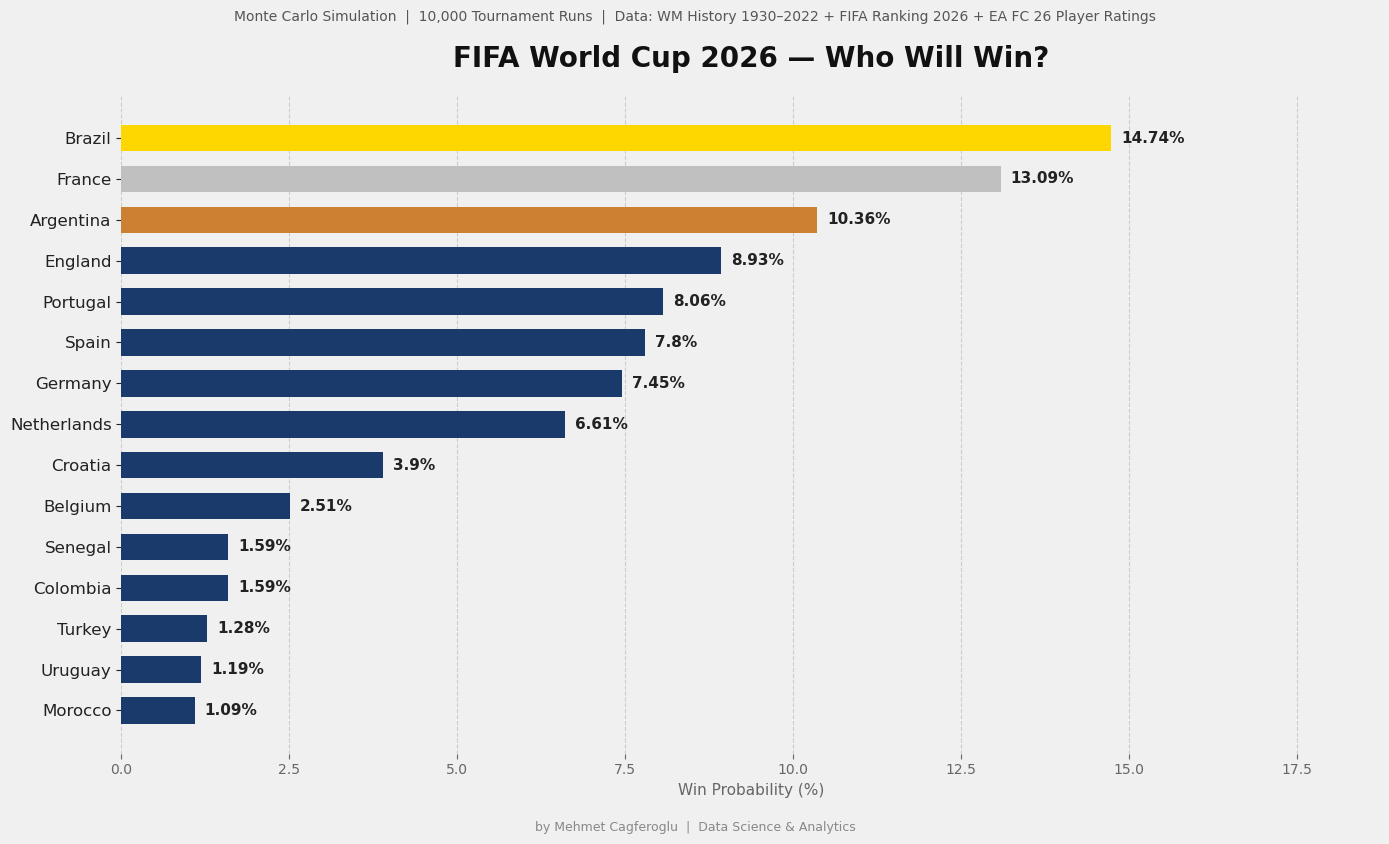

Chart saved.


In [121]:
# Step 14 - Final visualization (LinkedIn worthy)
#
# Light grey background, clean and professional.
# Gold for number 1, silver for 2, bronze for 3.

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

top15  = results.head(15)
teams  = top15['team'].tolist()[::-1]
values = top15['win_%'].tolist()[::-1]

colors = []
for i in range(len(teams)):
    if i == len(teams) - 1:
        colors.append('#FFD700')  # Gold
    elif i == len(teams) - 2:
        colors.append('#C0C0C0')  # Silver
    elif i == len(teams) - 3:
        colors.append('#CD7F32')  # Bronze
    else:
        colors.append('#1a3a6b')  # Dark blue

bars = ax.barh(teams, values, color=colors, height=0.65, edgecolor='none')

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', color='#222222', fontsize=11, fontweight='bold')

ax.tick_params(axis='y', colors='#222222', labelsize=12)
ax.tick_params(axis='x', colors='#666666', labelsize=10)
ax.xaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    'FIFA World Cup 2026 — Who Will Win?',
    color='#111111', fontsize=20, fontweight='bold', pad=20
)
fig.text(
    0.5, 0.92,
    f'Monte Carlo Simulation  |  {N:,} Tournament Runs  |  '
    f'Data: WM History 1930–2022 + FIFA Ranking 2026 + EA FC 26 Player Ratings',
    ha='center', color='#555555', fontsize=10
)
fig.text(
    0.5, 0.02,
    'by Mehmet Cagferoglu  |  Data Science & Analytics',
    ha='center', color='#888888', fontsize=9
)

ax.set_xlabel('Win Probability (%)', color='#666666', fontsize=11)
ax.set_xlim(0, values[-1] + 4)

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig('wm2026_prediction_linkedin.png', dpi=200, bbox_inches='tight', facecolor='#f0f0f0')
plt.show()
print("Chart saved.")

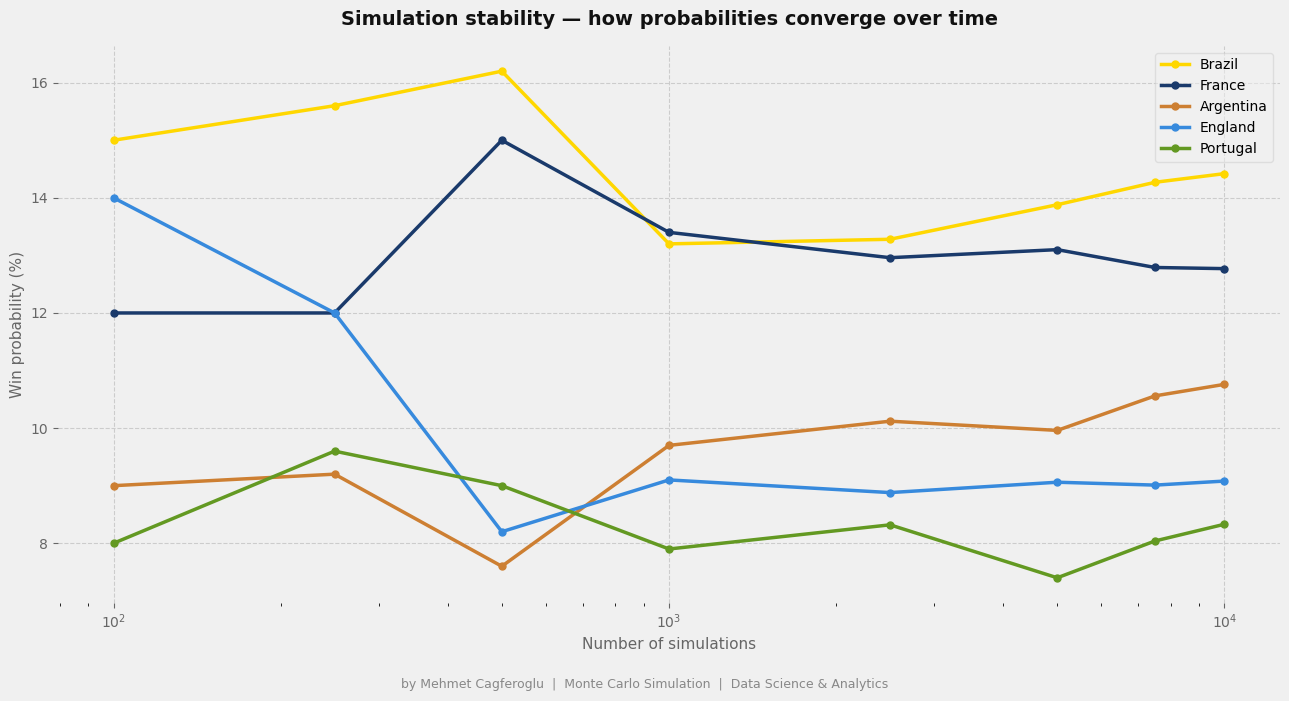

Stability diagram saved.


In [123]:
# Step 15 - Stability diagram
#
# We run the simulation multiple times with increasing N
# and track how the win probability for the top 5 teams changes.
# This shows why 10,000 runs gives more reliable results than 100.

checkpoints = [100, 250, 500, 1000, 2500, 5000, 7500, 10000]
top5 = results.head(5)['team'].tolist()

stability = {team: [] for team in top5}
win_counts_stab = {team: 0 for team in wm2026_teams}

checkpoint_idx = 0
for i in range(1, 10001):
    winner = simulate_tournament()
    if winner in win_counts_stab:
        win_counts_stab[winner] += 1
    if i == checkpoints[checkpoint_idx]:
        for team in top5:
            pct = round(win_counts_stab[team] / i * 100, 2)
            stability[team].append(pct)
        checkpoint_idx += 1
        if checkpoint_idx >= len(checkpoints):
            break

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

colors_line = ['#FFD700', '#1a3a6b', '#CD7F32', '#378ADD', '#639922']

for i, team in enumerate(top5):
    ax.plot(
        checkpoints,
        stability[team],
        color=colors_line[i],
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=team
    )

ax.set_xlabel('Number of simulations', color='#666666', fontsize=11)
ax.set_ylabel('Win probability (%)', color='#666666', fontsize=11)
ax.set_title(
    'Simulation stability — how probabilities converge over time',
    fontsize=14, fontweight='bold', color='#111111', pad=15
)
fig.text(
    0.5, 0.01,
    'by Mehmet Cagferoglu  |  Monte Carlo Simulation  |  Data Science & Analytics',
    ha='center', color='#888888', fontsize=9
)

ax.xaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='--')
ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(colors='#666666')
ax.set_xscale('log')
ax.legend(loc='upper right', framealpha=0.5, fontsize=10, facecolor='#f0f0f0')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('wm2026_stability.png', dpi=200, bbox_inches='tight', facecolor='#f0f0f0')
plt.show()
print("Stability diagram saved.")